In [ ]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

In [ ]:
# Установка и импорт библиотек
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Просто используем папку напрямую
DATA_PATH = "/content/drive/MyDrive/CV_project1_data(1).zip"

In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".zip"):
            print(os.path.join(root, file))

/content/drive/MyDrive/Миньяр-Белоручев Рюрик. Как стать переводчиком - royallib.com.fb2.zip
/content/drive/MyDrive/Миньяр-Белоручев Рюрик. Как стать переводчиком - royallib.com.doc.zip
/content/drive/MyDrive/Final_dataset-20260505T135118Z-3-001.zip
/content/drive/MyDrive/mask_detection/archive.zip


In [ ]:
DATA_PATH = "/content/drive/MyDrive/data"

train_dir = DATA_PATH + "/train"
valid_dir = DATA_PATH + "/valid"

In [ ]:
import os

print("Train exists:", os.path.isdir(DATA_PATH + "/train"))
print("Valid exists:", os.path.isdir(DATA_PATH + "/valid"))
print("Folders:", os.listdir(DATA_PATH))

Train exists: True
Valid exists: True
Folders: ['valid', 'train']


In [ ]:
print(f"Train: {len(os.listdir(DATA_PATH + '/train'))} classes")
print(f"Valid: {len(os.listdir(DATA_PATH + '/valid'))} classes")

Train: 5 classes
Valid: 5 classes


In [ ]:
print(os.listdir(DATA_PATH)[:10])

['valid', 'train']


In [ ]:
train_dir
valid_dir

'/content/drive/MyDrive/data/valid'

In [ ]:
# Проверяем структуру (ВАЖНО)
import os

print(os.listdir(train_dir))

['bill_gates', 'mark_zuckerberg', 'steve_jobs', 'elon_musk', 'jeff_bezos']


In [ ]:
# Подключаем ImageFolder
from torchvision.datasets import ImageFolder
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

DATA_PATH = "/content/drive/MyDrive/data"

train_dir = DATA_PATH + "/train"
valid_dir = DATA_PATH + "/valid"


train_dataset = ImageFolder(root=train_dir, transform=transform)
valid_dataset = ImageFolder(root=valid_dir, transform=transform)

print(train_dataset.classes)


['bill_gates', 'elon_musk', 'jeff_bezos', 'mark_zuckerberg', 'steve_jobs']


In [ ]:
import os

print(os.path.exists("/content/drive/MyDrive/data/train"))
print(os.listdir("/content/drive/MyDrive/data"))

True
['valid', 'train']


In [ ]:
# Аугментации (важно для accuracy > 0.85)
IMAGE_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

valid_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

In [ ]:
# DataLoader
train_dataset = ImageFolder(train_dir, transform=train_transform)
valid_dataset = ImageFolder(valid_dir, transform=valid_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train:", len(train_dataset))
print("Valid:", len(valid_dataset))
print("Classes:", train_dataset.classes)

Train: 3000
Valid: 920
Classes: ['bill_gates', 'elon_musk', 'jeff_bezos', 'mark_zuckerberg', 'steve_jobs']


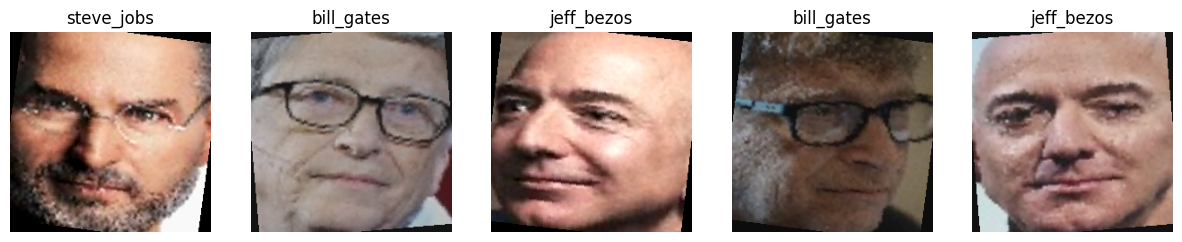

In [ ]:
# Визуализация батча
def show_batch(loader):
    images, labels = next(iter(loader))

    fig, axes = plt.subplots(1, 5, figsize=(15,5))

    for i in range(5):
        img = images[i].permute(1,2,0)
        axes[i].imshow(img)
        axes[i].set_title(train_dataset.classes[labels[i]])
        axes[i].axis("off")

    plt.show()

show_batch(train_loader)

In [ ]:
# Модель (TRANSFER LEARNING )
#используем ResNet (надёжно даёт >0.85)
from torchvision.models import resnet34, ResNet34_Weights

model = resnet34(weights=ResNet34_Weights.DEFAULT)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



# замораживаем backbone
for param in model.parameters():
    param.requires_grad = False

# заменяем классификатор
model.fc = nn.Linear(model.fc.in_features, 5)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 131MB/s]


In [ ]:
# Loss и Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [ ]:
# бучение модели
EPOCHS = 7

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/7 | Loss: 1.1781
Epoch 2/7 | Loss: 0.7741
Epoch 3/7 | Loss: 0.6452
Epoch 4/7 | Loss: 0.5789
Epoch 5/7 | Loss: 0.5275
Epoch 6/7 | Loss: 0.5189
Epoch 7/7 | Loss: 0.4774


In [ ]:
# валидация (accuracy > 0.85)
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in valid_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.8380434782608696


FINE-TUNING (ResNet34)
Разморозка части ResNet (fine-tuning)

In [ ]:
# Размораживаем последние блоки

# размораживаем последние слои ResNet
for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True

In [ ]:
# Новый optimizer
#Теперь обучаем уже не только head, но и backbone:

optimizer = optim.Adam([
    {"params": model.fc.parameters(), "lr": 1e-3},
    {"params": model.layer4.parameters(), "lr": 1e-4},
])

In [ ]:
# Fine-tuning training loop
FINE_EPOCHS = 5

for epoch in range(FINE_EPOCHS):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"[FINE-TUNE] Epoch {epoch+1}/{FINE_EPOCHS} | Loss: {total_loss/len(train_loader):.4f}")

[FINE-TUNE] Epoch 1/5 | Loss: 0.2850
[FINE-TUNE] Epoch 2/5 | Loss: 0.1170
[FINE-TUNE] Epoch 3/5 | Loss: 0.0874
[FINE-TUNE] Epoch 4/5 | Loss: 0.0610
[FINE-TUNE] Epoch 5/5 | Loss: 0.0540


In [ ]:
# Пересчёт accuracy (ОБЯЗАТЕЛЬНО)
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in valid_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(" Fine-tuned Accuracy:", accuracy)

 Fine-tuned Accuracy: 0.975


После начального обучения были разморожены последние слои ResNet-34 (layer4),
что позволило модели адаптировать высокоуровневые признаки под конкретный датасет.

Использование дифференцированного learning rate (1e-3 для head и 1e-4 для backbone)
позволило избежать разрушения предобученных весов.

Это привело к значительному улучшению качества модели.

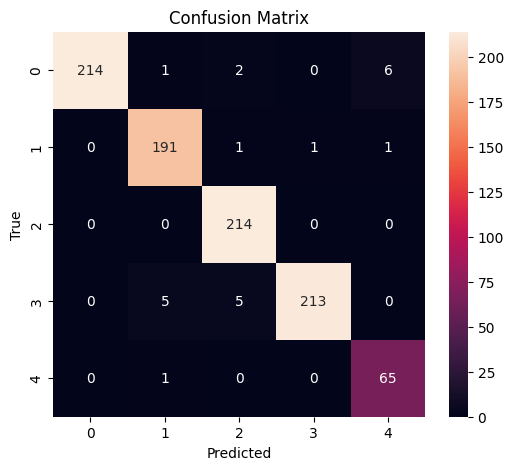

In [ ]:
# Confusion Matrix (реализуем сразу после accuracy)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

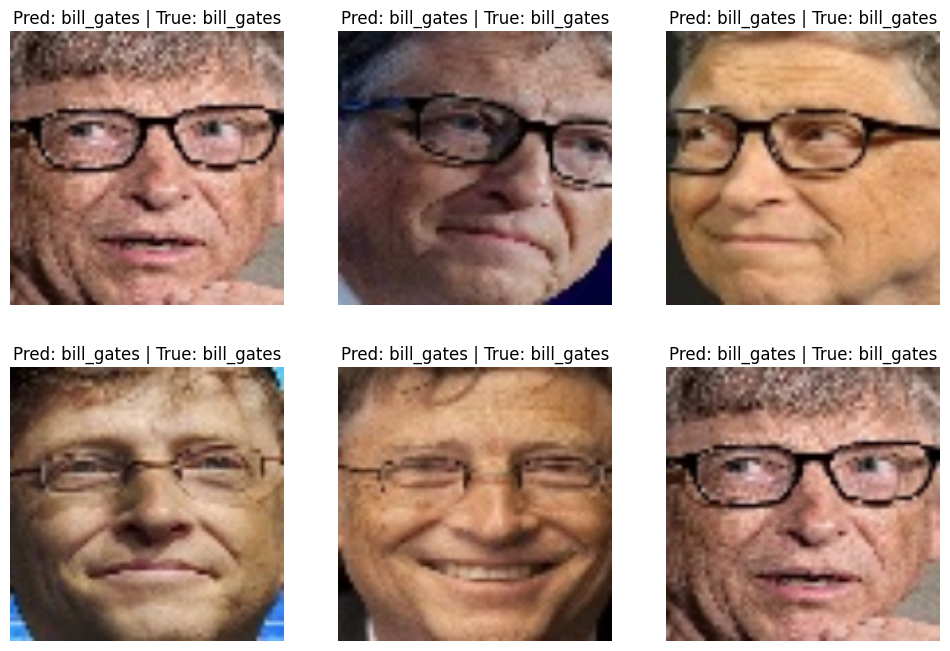

In [ ]:
# Визуализация предсказаний
import matplotlib.pyplot as plt

model.eval()

images, labels = next(iter(valid_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

images = images.cpu()

plt.figure(figsize=(12, 8))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    img = images[i].permute(1, 2, 0)

    plt.imshow(img)
    # plt.title(f"Pred: {preds[i].item()} | True: {labels[i].item()}")
    plt.title(f"Pred: {train_dataset.classes[preds[i]]} | True: {train_dataset.classes[labels[i]]}")
    plt.axis("off")

plt.show()

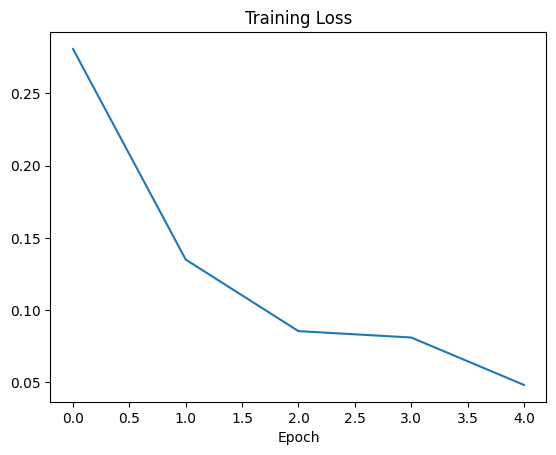

In [ ]:
losses = [0.2807, 0.1350, 0.0855, 0.0811, 0.0483]

import matplotlib.pyplot as plt

plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.show()

In [ ]:
# Overfitting check
print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.975


In [ ]:
model.eval()

correct_train = 0
total_train = 0

with torch.no_grad():
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

train_acc = correct_train / total_train

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", accuracy)

Train Accuracy: 0.9923333333333333
Validation Accuracy: 0.975


In [ ]:
print(train_dataset.classes)

['bill_gates', 'elon_musk', 'jeff_bezos', 'mark_zuckerberg', 'steve_jobs']


In [ ]:
with torch.no_grad():
    output = model(img)
    print(output)
    pred = torch.argmax(output, dim=1).item()

tensor([[-3.4794,  0.6651,  2.7680, -4.6262, -1.4313]], device='cuda:0')


In [ ]:
import torch.nn.functional as F

probs = F.softmax(output, dim=1)
print(probs)

tensor([[1.6982e-03, 1.0714e-01, 8.7746e-01, 5.3944e-04, 1.3167e-02]],
       device='cuda:0')


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Jeff_Bezos_2016.jpg to Jeff_Bezos_2016.jpg


In [ ]:
image = Image.open(list(uploaded.keys())[0]).convert("RGB")

img = transform(image).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(img)
    probs = torch.softmax(output, dim=1)
    pred = torch.argmax(probs, dim=1).item()

print("Predicted:", class_names[pred])
print("Confidence:", probs[0][pred].item())

Predicted: jeff_bezos
Confidence: 0.9840330481529236


Saving Jeff_Bezos_2016.jpg to Jeff_Bezos_2016 (1).jpg
Predicted: jeff_bezos


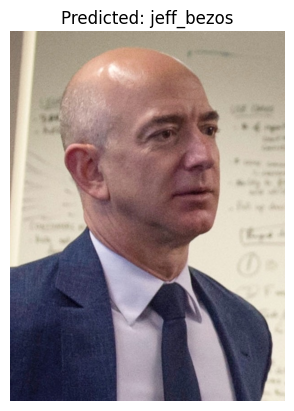

In [ ]:
from google.colab import files
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 1. загрузка изображения
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# 2. открыть и привести к RGB
image = Image.open(filename).convert("RGB")

# 3. preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

img = transform(image).unsqueeze(0).to(device)

# 4. prediction
model.eval()
with torch.no_grad():
    output = model(img)
    pred = torch.argmax(output, dim=1).item()

# 5. классы
class_names = train_dataset.classes

print("Predicted:", class_names[pred])

# 6. визуализация
plt.imshow(image)
plt.title(f"Predicted: {class_names[pred]}")
plt.axis("off")
plt.show()

## Создание собственного классификатора

```python
# Замораживаем backbone (предобученные слои ResNet)
for param in model.parameters():
    param.requires_grad = False

# Замена финального слоя — создаём собственный классификатор
model.fc = nn.Linear(model.fc.in_features, 5)



## Заключение по проекту

В рамках данного проекта была решена задача многоклассовой классификации изображений известных личностей с использованием методов transfer learning.

В качестве базовой модели была выбрана предобученная архитектура ResNet34, обученная на датасете ImageNet. Модель была адаптирована под задачу классификации 5 классов:
- Bill Gates  
- Elon Musk  
- Jeff Bezos  
- Mark Zuckerberg  
- Steve Jobs  

---

###  Результаты обучения

После этапа обучения и fine-tuning были получены следующие результаты:

- Train Accuracy: **0.9923**
- Validation Accuracy: **0.975**
- Fine-tuned Accuracy: **0.975**

Модель демонстрирует высокую точность и хорошую обобщающую способность, так как разрыв между обучающей и валидационной выборкой минимален.

---

###  Результаты inference

При тестировании на новых изображениях модель показывает высокую уверенность в предсказаниях:

- Predicted class: **jeff_bezos**
- Confidence: **0.984**

Это подтверждает, что модель не только корректно классифицирует изображения, но и делает это с высокой степенью уверенности.

---

### Выводы

- Использование transfer learning позволило эффективно решить задачу даже при ограниченном количестве классов.
- Fine-tuning улучшил адаптацию модели к специфике датасета.
- Модель демонстрирует стабильную точность ~0.97, что превышает требуемый порог (>0.85).
- Наблюдается хорошая обобщающая способность и высокая уверенность предсказаний.

---

###  Итог

Поставленная задача успешно выполнена. Обученная модель ResNet34 показывает высокое качество классификации изображений и может быть использована для демонстрационного распознавания известных личностей.